In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt


dataframe = pl.read_parquet("/run/media/mak/Heim/2024/20240826_week8/metashape/20241029_products_uav_data/output/extract/polygon_df/plot_4.parquet")
dataframe = dataframe.drop_nans()
dataframe



Xw,Yw,band1,band2,band3,band4,band5,elev,plot_id,delta_z,delta_x,delta_y,distance_xy,angle_rad,vza,vaa_rad,vaa_temp,vaa,xcam,ycam,sunelev,saa,path
f64,f64,f32,f32,f32,f32,f32,f32,str,f32,f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f32,f32,str
563624.527815,5.7130e6,0.016614,0.060436,0.02294,0.156945,0.36776,187.98999,"""plot_4""",19.556305,-14.652815,11.666251,18.729827,0.763815,43.76,-0.89839,-232.743832,127.256168,563609.875,5.713036e6,64.077271,181.269867,"""IMG_0197_6.tif"""
563624.535067,5.7130e6,0.022027,0.079677,0.033389,0.183523,0.427538,187.995514,"""plot_4""",19.550781,-14.660067,11.66616,18.735444,0.764106,43.78,-0.898635,-232.757862,127.242138,563609.875,5.713036e6,64.077271,181.269867,"""IMG_0197_6.tif"""
563624.542318,5.7130e6,0.027102,0.09494,0.039819,0.201914,0.45547,187.996445,"""plot_4""",19.54985,-14.667318,11.666069,18.741061,0.764279,43.79,-0.89888,-232.771884,127.228116,563609.875,5.713036e6,64.077271,181.269867,"""IMG_0197_6.tif"""
563624.549569,5.7130e6,0.027993,0.101211,0.042581,0.203373,0.46438,187.997375,"""plot_4""",19.54892,-14.674569,11.665978,18.746681,0.764453,43.8,-0.899124,-232.785897,127.214103,563609.875,5.713036e6,64.077271,181.269867,"""IMG_0197_6.tif"""
563624.556821,5.7130e6,0.027003,0.103226,0.041769,0.203811,0.457473,187.998764,"""plot_4""",19.547531,-14.681821,11.665887,18.752301,0.764638,43.81,-0.899369,-232.799902,127.200098,563609.875,5.713036e6,64.077271,181.269867,"""IMG_0197_6.tif"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
563628.004746,5.7130e6,0.034106,0.100804,0.04691,0.224748,0.428241,187.899323,"""plot_4""",19.695526,-20.129746,29.138784,35.415751,1.063264,60.92,-0.60454,-218.408089,141.591911,563607.875,5713051.5,48.344837,183.770477,"""IMG_0194_6.tif"""
563628.011998,5.7130e6,0.059582,0.140446,0.06988,0.293004,0.546556,187.906006,"""plot_4""",19.688843,-20.136998,29.138693,35.419798,1.063457,60.93,-0.60471,-218.417823,141.582177,563607.875,5713051.5,48.344837,183.770477,"""IMG_0194_6.tif"""
563628.019249,5.7130e6,0.071486,0.169318,0.092623,0.336975,0.60035,187.907425,"""plot_4""",19.687424,-20.144249,29.138602,35.423846,1.063536,60.94,-0.60488,-218.427556,141.572444,563607.875,5713051.5,48.344837,183.770477,"""IMG_0194_6.tif"""


In [2]:
# Convert sun elevation to zenith angle
dataframe = dataframe.with_columns((90 - pl.col("sunelev")).alias("sza"))

# Calculate relative azimuth angle constrained to [0,180]
dataframe = dataframe.with_columns(
    (((pl.col("saa") - pl.col("vaa") + 180) % 360) - 180).alias("RAA")
)

dataframe

Xw,Yw,band1,band2,band3,band4,band5,elev,plot_id,delta_z,delta_x,delta_y,distance_xy,angle_rad,vza,vaa_rad,vaa_temp,vaa,xcam,ycam,sunelev,saa,path,sza,RAA
f64,f64,f32,f32,f32,f32,f32,f32,str,f32,f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f32,f32,str,f32,f64
563624.527815,5.7130e6,0.016614,0.060436,0.02294,0.156945,0.36776,187.98999,"""plot_4""",19.556305,-14.652815,11.666251,18.729827,0.763815,43.76,-0.89839,-232.743832,127.256168,563609.875,5.713036e6,64.077271,181.269867,"""IMG_0197_6.tif""",25.922729,54.013699
563624.535067,5.7130e6,0.022027,0.079677,0.033389,0.183523,0.427538,187.995514,"""plot_4""",19.550781,-14.660067,11.66616,18.735444,0.764106,43.78,-0.898635,-232.757862,127.242138,563609.875,5.713036e6,64.077271,181.269867,"""IMG_0197_6.tif""",25.922729,54.027729
563624.542318,5.7130e6,0.027102,0.09494,0.039819,0.201914,0.45547,187.996445,"""plot_4""",19.54985,-14.667318,11.666069,18.741061,0.764279,43.79,-0.89888,-232.771884,127.228116,563609.875,5.713036e6,64.077271,181.269867,"""IMG_0197_6.tif""",25.922729,54.041751
563624.549569,5.7130e6,0.027993,0.101211,0.042581,0.203373,0.46438,187.997375,"""plot_4""",19.54892,-14.674569,11.665978,18.746681,0.764453,43.8,-0.899124,-232.785897,127.214103,563609.875,5.713036e6,64.077271,181.269867,"""IMG_0197_6.tif""",25.922729,54.055764
563624.556821,5.7130e6,0.027003,0.103226,0.041769,0.203811,0.457473,187.998764,"""plot_4""",19.547531,-14.681821,11.665887,18.752301,0.764638,43.81,-0.899369,-232.799902,127.200098,563609.875,5.713036e6,64.077271,181.269867,"""IMG_0197_6.tif""",25.922729,54.069769
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
563628.004746,5.7130e6,0.034106,0.100804,0.04691,0.224748,0.428241,187.899323,"""plot_4""",19.695526,-20.129746,29.138784,35.415751,1.063264,60.92,-0.60454,-218.408089,141.591911,563607.875,5713051.5,48.344837,183.770477,"""IMG_0194_6.tif""",41.655163,42.178566
563628.011998,5.7130e6,0.059582,0.140446,0.06988,0.293004,0.546556,187.906006,"""plot_4""",19.688843,-20.136998,29.138693,35.419798,1.063457,60.93,-0.60471,-218.417823,141.582177,563607.875,5713051.5,48.344837,183.770477,"""IMG_0194_6.tif""",41.655163,42.188301
563628.019249,5.7130e6,0.071486,0.169318,0.092623,0.336975,0.60035,187.907425,"""plot_4""",19.687424,-20.144249,29.138602,35.423846,1.063536,60.94,-0.60488,-218.427556,141.572444,563607.875,5713051.5,48.344837,183.770477,"""IMG_0194_6.tif""",41.655163,42.198033


In [3]:
from typing import List, Tuple, Optional
import logging
from scipy.ndimage import gaussian_filter1d


def _kde1d_fast(
    v: np.ndarray,
    x_grid: np.ndarray,
    bw: float | None = None,
    bins: int = 1024,
    vmin: float | None = None,
    vmax: float | None = None,
) -> np.ndarray:
    """
    Approximate 1D KDE efficiently via histogram + Gaussian smoothing.

    Steps:
    1) Bin values into a fine histogram.
    2) Smooth counts with gaussian_filter1d using sigma derived from bandwidth.
    3) Interpolate smoothed density to x_grid and normalize to integrate to ~1.

    Args:
        v: 1D array of finite samples.
        x_grid: Points where the PDF should be evaluated.
        bw: Bandwidth in data units. If None, use Scott's rule.
        bins: Number of histogram bins for the smoothing grid.
        vmin, vmax: Optional clipping range. If None, inferred from data.

    Returns:
        y_pdf evaluated at x_grid (approximately normalized).
    """
    v = v[np.isfinite(v)]
    if v.size < 5:
        return np.zeros_like(x_grid)

    # Range and histogram grid
    lo = np.min(v) if vmin is None else float(vmin)
    hi = np.max(v) if vmax is None else float(vmax)
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo, hi = float(np.nanmin(v)), float(np.nanmax(v))
        if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
            return np.zeros_like(x_grid)

    edges = np.linspace(lo, hi, bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    counts, _ = np.histogram(v, bins=edges)

    # Bandwidth: Scott's rule if not provided
    if bw is None:
        s = np.std(v)
        n = v.size
        # Scott's rule: bw = 1.06 * s * n^(-1/5); fallback if s==0
        bw = 1.06 * (s if s > 0 else (hi - lo) / 6.0) * (n ** (-1.0 / 5.0))
        if bw <= 0 or not np.isfinite(bw):
            bw = max((hi - lo) / 100.0, 1e-12)

    # Convert bandwidth to sigma in bins
    bin_width = centers[1] - centers[0]
    sigma_bins = max(bw / bin_width, 1e-6)

    # Smooth counts
    smooth = gaussian_filter1d(counts.astype(float), sigma=sigma_bins, mode="nearest")

    # Convert to density (divide by N and bin width)
    density_centers = smooth / (v.size * bin_width)

    # Interpolate to requested x_grid
    y_pdf = np.interp(x_grid, centers, density_centers, left=0.0, right=0.0)

    # Normalize lightly to ensure area ≈ 1 over [lo, hi]
    area = np.trapezoid(y_pdf, x_grid)
    if area > 0 and np.isfinite(area):
        y_pdf = y_pdf / area

    return y_pdf

def angle_kde_plot(
    df,
    band: str,
    bins: Tuple[int, int],
    angle: str,
    xlim: Optional[Tuple[float, float]],
    points: int,
    linewidth: float,
    colors: Optional[List[str]],
    dpi: int,
    ) -> None:
    try:
        df = df.drop_nulls().drop_nans()
        if xlim is not None:
            x_min, x_max = xlim
        else:
            x_min = df.select(pl.col(band).quantile(0.01)).item()
            x_max = df.select(pl.col(band).quantile(0.98)).item()
            print(x_min, x_max)
        x_grid = np.linspace(x_min, x_max, int(points))
        fig_k, ax_k = plt.subplots(figsize=(10, 6), dpi=dpi)

        cycle = colors or plt.rcParams["axes.prop_cycle"].by_key().get("color", None)

        i = 0
        for bin in bins:

            filtered_df = df.filter(
                pl.col(angle)>bin[0],
                pl.col(angle)<bin[1],
            )

            v = filtered_df[band].to_numpy()
            # Restrict to finite values within [x_min, x_max] to match chart limits
            v = v[np.isfinite(v)]
            v = v[(v >= x_min) & (v <= x_max)]
            if v.size < 5:
                continue

            # Fast KDE via histogram smoothing (orders of magnitude faster than gaussian_kde on big data)
            y_pdf = _kde1d_fast(
                v,
                x_grid,
                bw=None,  # or set a float bandwidth in data units (e.g., 0.01)
                bins=5128,  # can lower to 512 for even faster
                vmin=x_min,
                vmax=x_max,
            )

            color = None
            if cycle and i < len(cycle):
                color = cycle[i]
            ax_k.plot(x_grid, y_pdf, label=f"{bin[0]},{bin[1]}", linewidth=linewidth, color=color)
            i+=1

        ax_k.set_xlim(x_min, x_max)
        ax_k.set_ylim(bottom=0.0)
        ax_k.set_xlabel("Reflectance")
        ax_k.set_ylabel("Density (KDE)")
        ax_k.set_title(f"{band} value distributions(KDE) by different {angle} bins ")
        ax_k.grid(True, alpha=0.3)
        ax_k.legend(ncol=2)
        fig_k.tight_layout()
        fig_k.show()
    except Exception as e:
        logging.error(f"[plotting_raster] Failed to create band KDE chart: {e}")



0.11028822511434555 0.6811746954917908


/tmp/ipykernel_4720/1111078562.py:140: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_k.show()


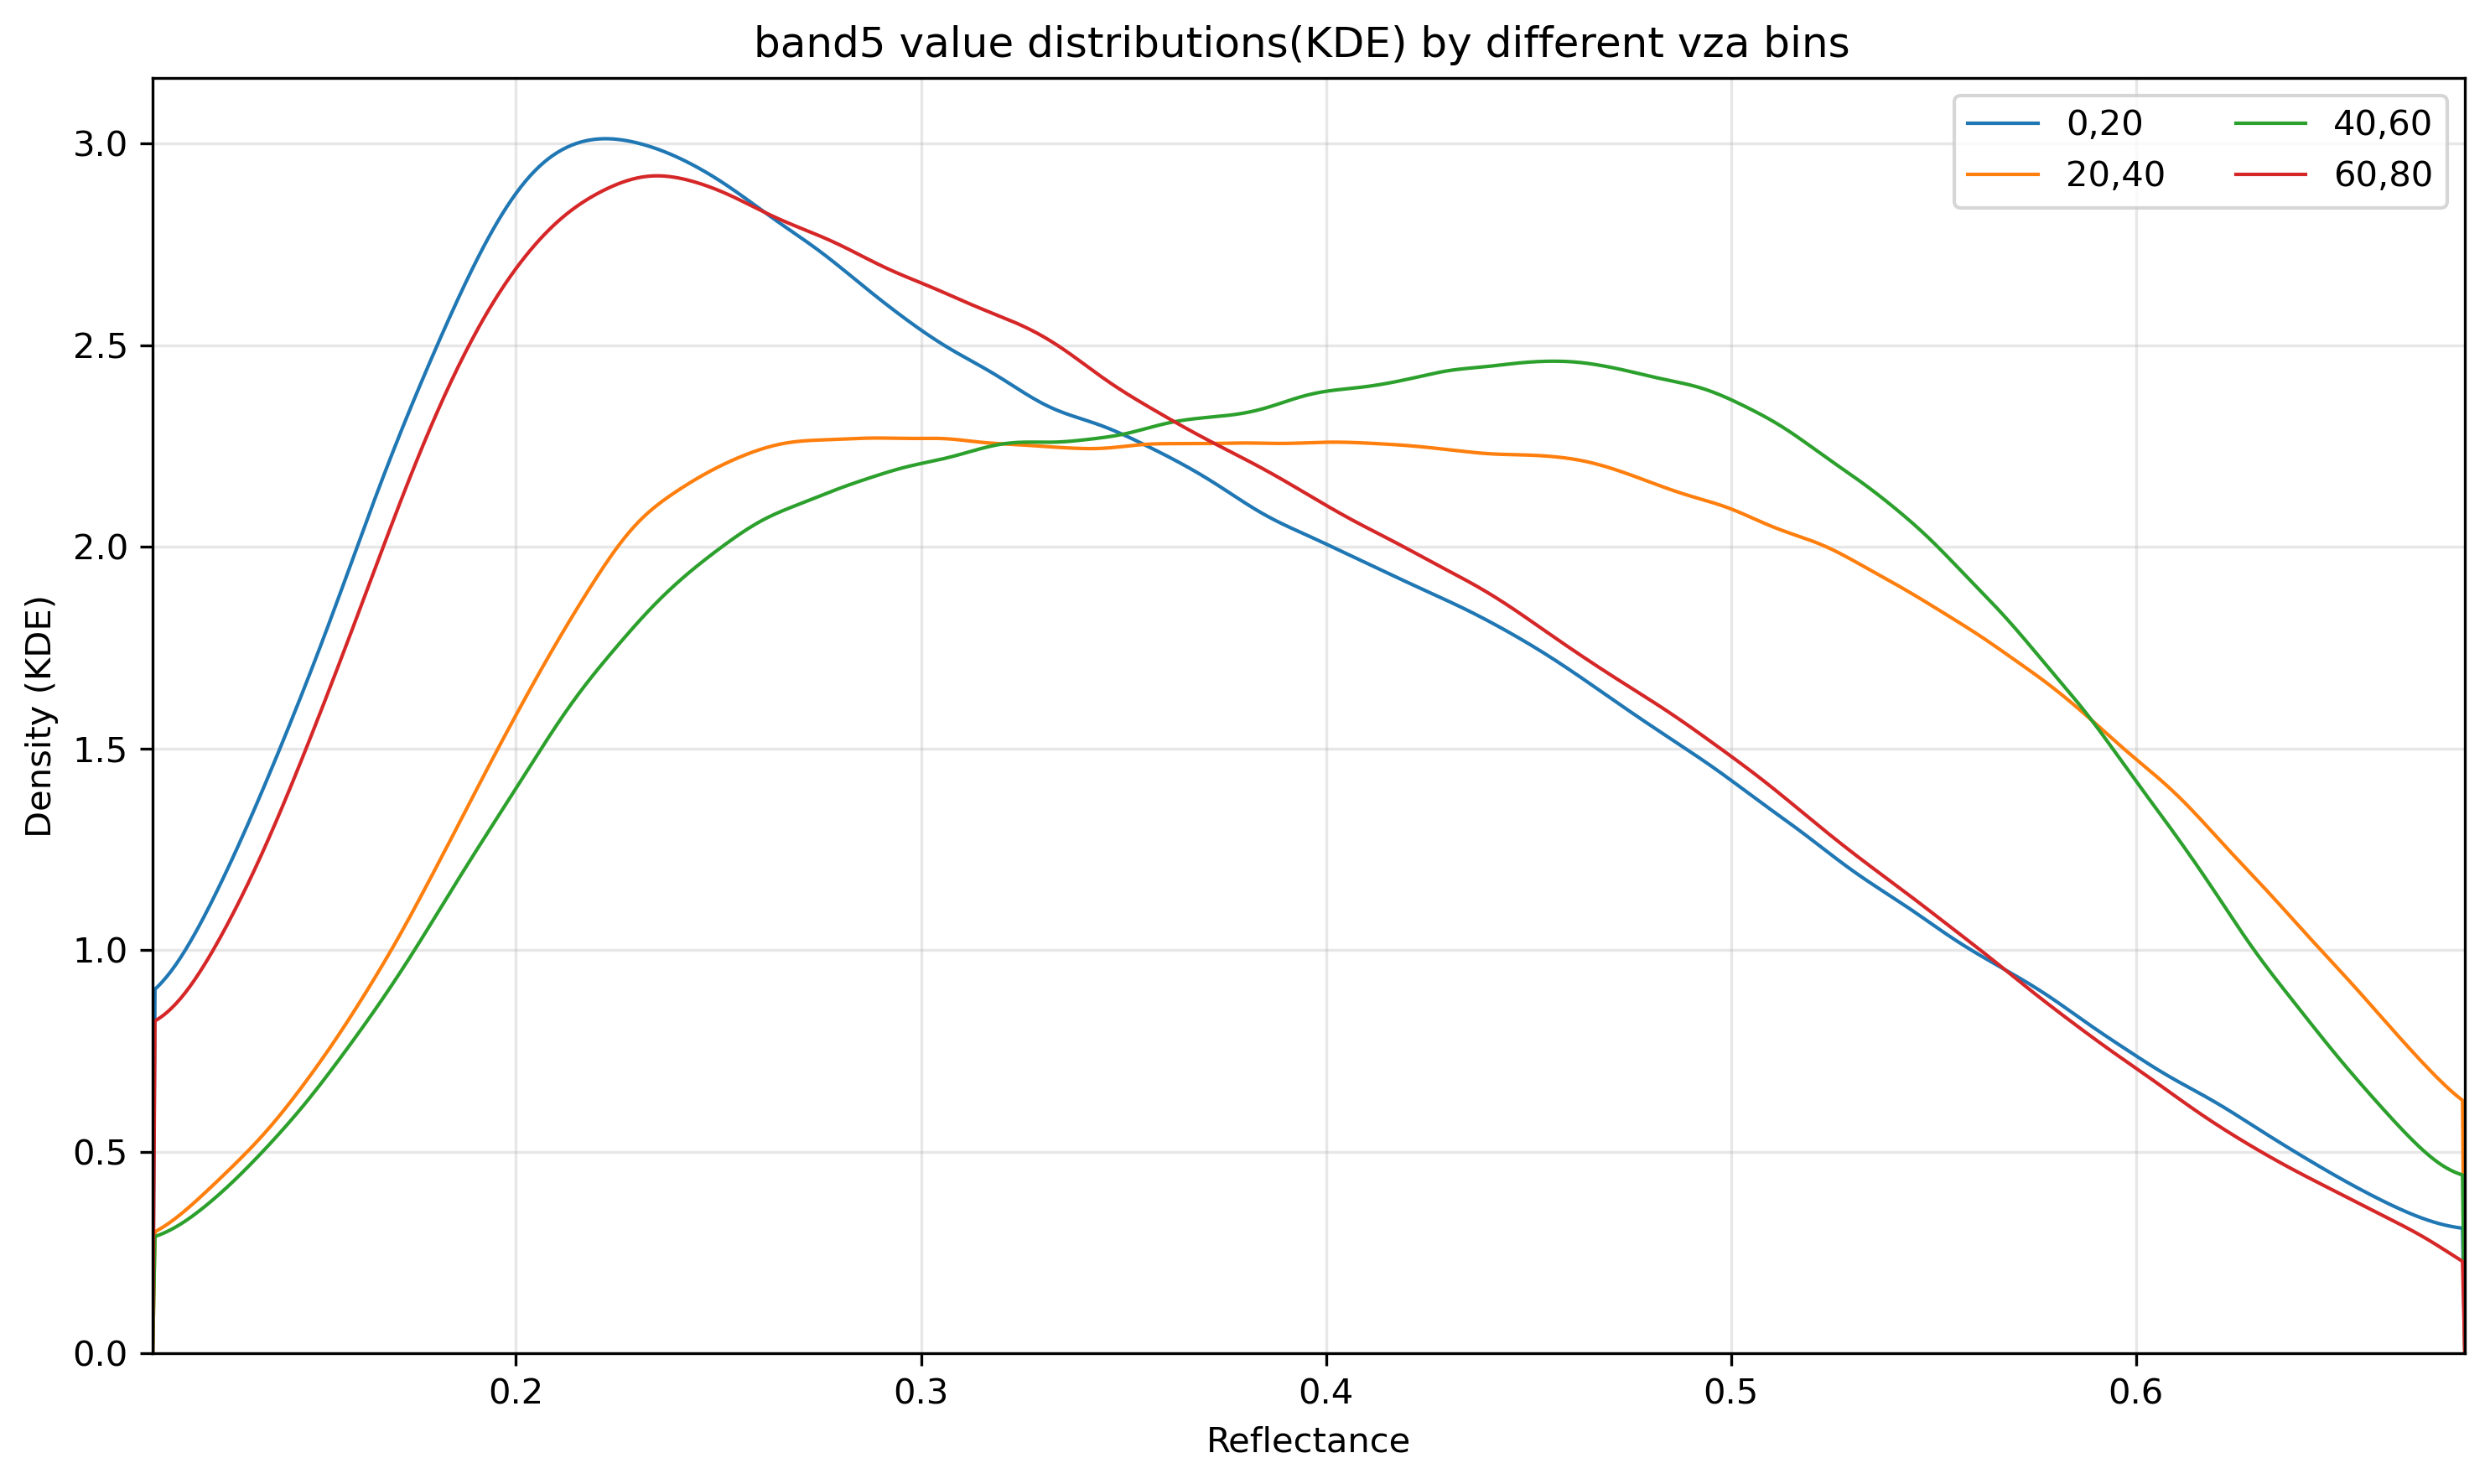

In [4]:
vza_bins = [(0,20),(20,40),(40,60),(60,80)]

for band in [f"band{i}" for i in range(5,6)]:
    angle_kde_plot(dataframe, band=band, bins=vza_bins, points=1000, linewidth=1, colors=None, dpi=300, xlim=None, angle='vza')

[(-450, -360), (-360, -270), (-270, -180), (-180, -90), (-90, 0), (0, 90), (90, 180), (180, 270), (270, 360)]
0.09670940041542053 0.6682747006416321


/tmp/ipykernel_4720/1111078562.py:140: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_k.show()


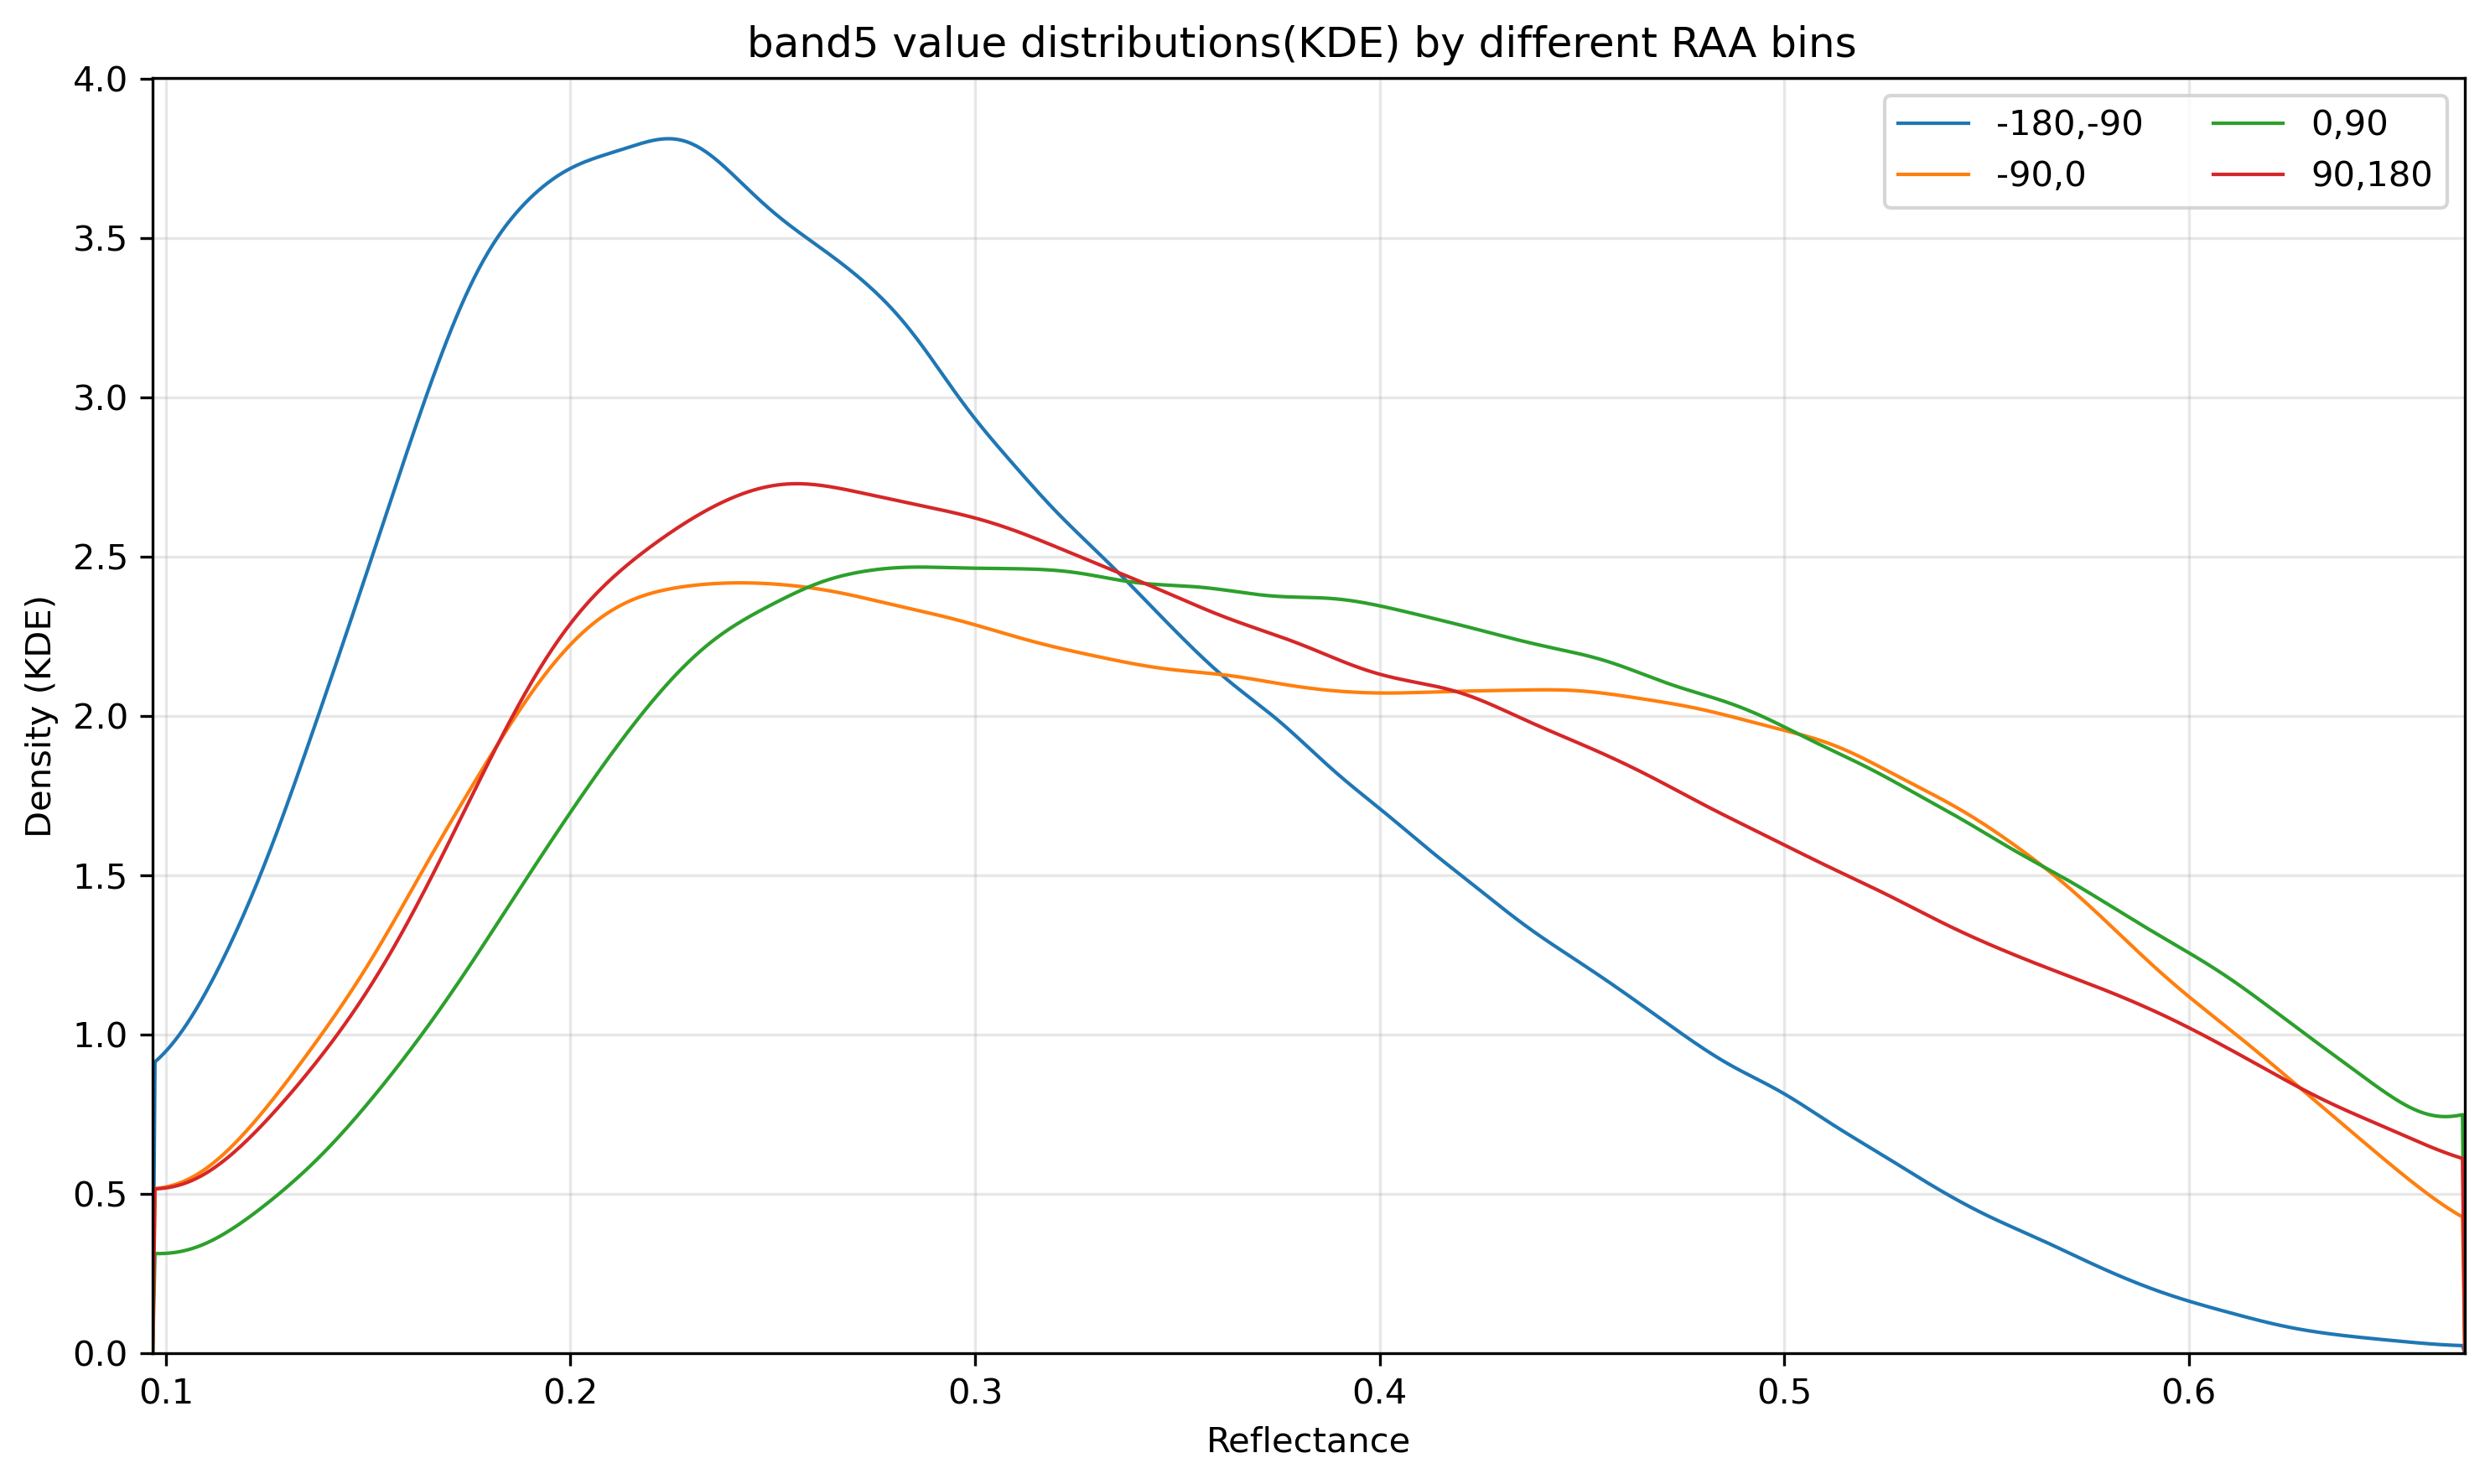

In [39]:
vaa_bins = [(i-90, i) for i in   range(-360,361,90)]
print(vaa_bins)
for band in [f"band{i}" for i in range(5,6)]:
    angle_kde_plot(dataframe, band=band, bins=vaa_bins, points=1000, linewidth=1, colors=None, dpi=300, xlim=None, angle='RAA')

In [6]:
def assign_bin(v):
    for lo, hi in vaa_bins:
        if lo <= v < hi:
            return f"{lo}-{hi}"   # hashable
    return None

dataframe = dataframe.with_columns(
    pl.col("RAA").map_elements(assign_bin, return_dtype=pl.Utf8).alias("raa_bin")
).drop_nulls("raa_bin")


def assign_bin(v):
    for lo, hi in vza_bins:
        if lo <= v < hi:
            return f"{lo}-{hi}"
    return None

dataframe = dataframe.with_columns(
    pl.col("vza").map_elements(assign_bin, return_dtype=pl.Utf8).alias("vza_bin")
).drop_nulls("vza_bin")


In [7]:
dataframe = dataframe.with_columns(
    pl.when((pl.col("vaa") >= 0) & (pl.col("vaa") < 90)).then(1)
     .when((pl.col("vaa") >= 90) & (pl.col("vaa") < 180)).then(2)
     .when((pl.col("vaa") >= 180) & (pl.col("vaa") < 270)).then(3)
     .when((pl.col("vaa") >= 270) & (pl.col("vaa") < 360)).then(4)
     .alias("bin_vaa")
)

min_count = dataframe.group_by("bin_vaa").len()["len"].min()

# sample equally from each bin
dataframe = (
    dataframe.group_by("bin_vaa", maintain_order=True)
      .map_groups(lambda g: g.sample(n=min_count, shuffle=True))
)



In [8]:
import polars as pl
import numpy as np
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import f as f_dist, studentized_range
import time
import numpy as np
import polars as pl
import itertools




def descriptive_statistics(dataframe, band_col, angle_col):
    df = dataframe.select([angle_col, band_col]).drop_nulls().filter(pl.col(band_col).is_finite())

    group_summary = (
        df.group_by(angle_col)
           .agg([
               pl.len().alias("n"),
               pl.col(band_col).mean().alias("mean"),
               pl.col(band_col).std().alias("sd"),
               pl.col(band_col).median().alias("median"),
               pl.col(band_col).quantile(0.90).alias("q90"),
               pl.col(band_col).quantile(0.99).alias("q99"),
           ])
           .with_columns([
               (pl.col("sd")/pl.col("n").cast(pl.Float64).sqrt()).alias("se"),
               (pl.col("mean")-1.96*pl.col("sd")/pl.col("n").cast(pl.Float64).sqrt()).alias("ci_lo"),
               (pl.col("mean")+1.96*pl.col("sd")/pl.col("n").cast(pl.Float64).sqrt()).alias("ci_hi"),
           ])
           .sort("mean", descending=True)
    )

    return group_summary

def ANOVA(dataframe, band_col):

    ## ANOVA MAIN
    dfc = (dataframe.select(["vza_bin", band_col]).drop_nulls().filter(pl.col(band_col).is_finite()))



    # Set up multiple comparison analysis using Tukey's HSD test
    # MultiComparison requires the dependent variable (band1) and grouping variable (vza_bin)
    tk = pairwise_tukeyhsd(dfc[band_col].to_numpy(), dfc["vza_bin"].to_numpy())
    rows = tk.summary().data[1:]  # trusted order: group1, group2, meandiff, p-adj, lower, upper, reject



    # Generate all possible pairwise combinations of groups for comparison
    # This creates tuples like (group1, group2), (group1, group3), etc.
    # per-bin vectors for effect sizes
    grp = {g: dfc.filter(pl.col("vza_bin") == g)[band_col].to_numpy() for g in tk.groupsunique}



    # Define function to calculate Cohen's d (effect size measure)
    # Cohen's d = (mean1 - mean2) / pooled_standard_deviation
    def cd(a, b):
        n1, n2 = len(a), len(b)  # Sample sizes for each group
        s1 = np.var(a, ddof=1)   # Variance of group 1 (sample variance)
        s2 = np.var(b, ddof=1)   # Variance of group 2 (sample variance)

        # Calculate pooled standard deviation
        sp = np.sqrt(((n1-1)*s1 + (n2-1)*s2) / (n1+n2-2))

        # Return Cohen's d: difference in means divided by pooled standard deviation
        return (np.mean(a) - np.mean(b)) / sp

    # Calculate Cohen's d for all pairwise comparisons
    g1 = [r[0] for r in rows]
    g2 = [r[1] for r in rows]
    meandiff = np.array([r[2] for r in rows], float)
    p = np.array([r[3] for r in rows], float)
    lower = np.array([r[4] for r in rows], float)
    upper = np.array([r[5] for r in rows], float)
    reject = np.array([r[6] for r in rows], bool)
    d = [abs(cd(grp[a], grp[b])) for a, b in zip(g1, g2)]
    tiny = np.nextafter(0, 1); nlog10 = -np.log10(np.clip(p, tiny, 1.0))
    ptxt = [("p < 0.0001" if (x == 0 or x < 1e-300) else f"{x:.3e}") for x in p]



    #F statistic
    groups = [grp[g] for g in tk.groupsunique]
    ns     = [len(a) for a in groups]
    means  = [a.mean() for a in groups]
    N, k   = sum(ns), len(groups)
    grand  = sum(n*m for n, m in zip(ns, means)) / N
    SSB    = sum(n * (m - grand)**2 for n, m in zip(ns, means))
    SSW    = sum(((a - m)**2).sum() for a, m in zip(groups, means))
    dfn, dfd = k - 1, N - k
    MSB, MSW = SSB / dfn, SSW / dfd
    F = MSB / MSW
    p_global = f_dist.sf(F, dfn, dfd)
    neglog10p = -np.log10(np.clip(p_global, np.nextafter(0,1), 1.0))
    eta_sq = SSB / (SSB + SSW)



    # Create comprehensive results table with all statistical measures
    tbl = pl.DataFrame({
        "group1": g1,        # First group in each comparison
        "group2": g2,        # Second group in each comparison
        "mean group 2 - group1": meandiff,               # Mean difference between group2 - group1
        "CI+-": upper - lower,              # Lower confidence interval bound
        "p_text": ptxt,                         # Formatted p-values for display
        "-log10_p": nlog10,                     # Negative log10 p-values (significance strength)
        "cohens_d":d,                          # Effect size (Cohen's d)
        "reject": reject                     # Boolean: reject null hypothesis?
    }).with_columns(
        pl.col("-log10_p").round(3),           # Round -log10 p-values to 3 decimals
        pl.col("cohens_d").round(3),           # per-pair standardized effect size |mean1-mean2|/spooled
        pl.lit(F).alias("F_global"),           # one-way ANOVA F-statistic across vza_bin for THIS band
        pl.lit(dfn/dfd).round(10).alias("degrees of freedom"),       # degrees of freedom: numerator df = k - 1 (k = number of bins)  /
                                                                     # denominator df = N - k (N = total observations)
        pl.lit(eta_sq).round(3).alias("eta_sq")                      # effect size: SSB / (SSB + SSW), variance explained by vza_bin
    )

    tbl.sort("cohens_d",descending=True)


    return tbl

def ANOVA_optimized(dataframe, band_col, col=None):
    """
    Optimized ANOVA implementation with custom Tukey's HSD for large datasets.
    Uses Polars and NumPy for efficient computation of statistics.

    Args:
        dataframe: A Polars DataFrame
        band_col: Column name containing the dependent variable
    """

    # Start with lazy operations to optimize memory usage
    # Select only necessary columns, remove nulls and non-finite values
    lazy_df = dataframe.lazy().select([col, band_col]).drop_nulls().filter(pl.col(band_col).is_finite())

    # Calculate all group statistics in a single efficient pass
    # This avoids multiple passes through the data for each statistic
    group_stats = (lazy_df.group_by(col)
                     .agg([
                         pl.col(band_col).count().alias("n"),              # Sample size per group
                         pl.col(band_col).mean().alias("mean"),            # Group means
                         pl.col(band_col).var().alias("var"),              # Group variances
                         pl.col(band_col).sum().alias("sum")               # Group sums (for calculations)
                     ])
                     .collect())  # Execute the lazy computation

    # Extract statistics for calculations
    groups = group_stats[col].to_numpy()
    ns = group_stats["n"].to_numpy()
    means = group_stats["mean"].to_numpy()
    variances = group_stats["var"].to_numpy()

    # Calculate ANOVA statistics
    N = sum(ns)                                   # Total sample size
    k = len(groups)                               # Number of groups
    grand_mean = sum(n*m for n, m in zip(ns, means)) / N  # Overall mean

    # Between-group sum of squares (variation explained by group differences)
    SSB = sum(n * (m - grand_mean)**2 for n, m in zip(ns, means))

    # Within-group sum of squares (variation not explained by groups)
    SSW = sum((n-1) * v for n, v in zip(ns, variances))

    # Calculate F-statistic and p-value
    dfn, dfd = k - 1, N - k                       # Degrees of freedom (between and within groups)
    MSB, MSW = SSB / dfn, SSW / dfd               # Mean squares (between and within)
    F = MSB / MSW                                 # F statistic (ratio of between to within variation)
    p_global = f_dist.sf(F, dfn, dfd)             # Global p-value for ANOVA
    eta_sq = SSB / (SSB + SSW)                    # Effect size (proportion of variance explained)

    # Collect full dataset for pairwise comparisons
    dfc = lazy_df.collect()

    # Generate all unique pairs of groups for comparison
    # This creates tuples like (group1, group2), (group1, group3), etc.
    pairs = list(itertools.combinations(groups, 2))

    # Pre-compute statistics for each group once to avoid repeated calculations
    # This is more efficient than extracting the data repeatedly
    group_data = {}
    for g in groups:
        group_data[g] = {
            'mean': dfc.filter(pl.col(col) == g)[band_col].mean(),
            'n': dfc.filter(pl.col(col) == g).height,
            'var': dfc.filter(pl.col(col) == g)[band_col].var()
        }

    # Custom implementation of Tukey's HSD test
    # This avoids the slower implementation in statsmodels
    results = []
    for g1, g2 in pairs:
        # Extract pre-computed statistics for the pair
        mean1 = group_data[g1]['mean']
        mean2 = group_data[g2]['mean']
        n1 = group_data[g1]['n']
        n2 = group_data[g2]['n']
        var1 = group_data[g1]['var']
        var2 = group_data[g2]['var']

        # Calculate mean difference between groups
        meandiff = mean2 - mean1

        # Calculate pooled standard error for Tukey's HSD
        se = np.sqrt(MSW * (1/n1 + 1/n2))

        # Calculate q statistic for Tukey's HSD
        q = abs(meandiff) / se

        # Calculate critical q value for confidence intervals
        q_crit = studentized_range.ppf(0.99, k, dfd)

        # Calculate confidence interval bounds
        lower = meandiff - q_crit * se
        upper = meandiff + q_crit * se

        # Calculate adjusted p-value for the comparison
        p = studentized_range.sf(q, k, dfd)

        # Calculate Cohen's d effect size (standardized mean difference)
        # Pooled standard deviation using weighted average of group variances
        sp = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
        cohens_d = abs(mean1 - mean2) / sp

        # Determine if null hypothesis is rejected (alpha = 0.005)
        reject = (p < 0.005)

        # Store results for this pair
        results.append({
            'group1': g1,
            'group2': g2,
            'meandiff': meandiff,
            'lower': lower,
            'upper': upper,
            'p_adj': p,
            'cohens_d': cohens_d,
            'reject': reject
        })

    # Format results for output DataFrame
    g1 = [r['group1'] for r in results]
    g2 = [r['group2'] for r in results]
    meandiff = [r['meandiff'] for r in results]
    p = [r['p_adj'] for r in results]
    lower = [r['lower'] for r in results]
    upper = [r['upper'] for r in results]
    cohens_d = [r['cohens_d'] for r in results]
    reject = [r['reject'] for r in results]

    # Process significance levels for display
    tiny = np.nextafter(0, 1)  # Smallest positive float for handling very small p-values
    nlog10 = -np.log10(np.clip(p, tiny, 1.0))  # Negative log10 of p-values (higher = more significant)
    ptxt = [("p < 0.0001" if (x == 0 or x < 1e-4) else f"{x:.3e}") for x in p]  # Formatted p-values

    # Calculate confidence interval range
    CI_range = [u - l for u, l in zip(upper, lower)]

    # Create comprehensive results table with all statistical measures
    tbl = pl.DataFrame({
        "group1": g1,                        # First group in each comparison
        "group2": g2,                        # Second group in each comparison
        "mean group 2 - group1": meandiff,   # Mean difference between group2 - group1
        "CI+-": CI_range,                    # Confidence interval range
        "p_text": ptxt,                      # Formatted p-values for display
        "-log10_p": nlog10,                  # Negative log10 p-values (significance strength)
        "cohens_d": cohens_d,                # Effect size (Cohen's d)
        "reject": reject                     # Boolean: reject null hypothesis?
    }).with_columns([
        pl.col("-log10_p").round(3),         # Round -log10 p-values to 3 decimals
        pl.col("cohens_d").round(3),         # Round Cohen's d to 3 decimals
        pl.lit(F).alias("F_global"),         # One-way ANOVA F-statistic across vza_bin for this band
        pl.lit(dfn/dfd).round(10).alias("degrees of freedom"),  # Degrees of freedom ratio
        pl.lit(eta_sq).round(3).alias("eta_sq")  # Effect size: variance explained by vza_bin
    ])

    # Sort by effect size (largest effects first)
    result = tbl.sort("cohens_d", descending=True)

    return result


In [9]:


descriptive_statistics(dataframe=dataframe, band_col="band5", angle_col = "raa_bin")


raa_bin,n,mean,sd,median,q90,q99,se,ci_lo,ci_hi
str,u32,f32,f32,f32,f32,f32,f64,f64,f64
"""0-90""",602299,0.390746,0.145245,0.381356,0.592576,0.714782,0.000187,0.39038,0.391113
"""-90-0""",617158,0.369767,0.14753,0.360892,0.572153,0.688205,0.000188,0.369399,0.370135
"""90-180""",305189,0.367443,0.150656,0.347806,0.583899,0.727532,0.000273,0.366908,0.367977
"""-180--90""",406638,0.282913,0.114759,0.265303,0.448105,0.577334,0.00018,0.282561,0.283266


In [10]:
ANOVA_optimized(dataframe=dataframe, band_col="band5", col = "raa_bin")


group1,group2,mean group 2 - group1,CI+-,p_text,-log10_p,cohens_d,reject,F_global,degrees of freedom,eta_sq
str,str,f64,f64,str,f64,f64,bool,f64,f64,f64
"""0-90""","""-180--90""",-0.107828,0.002521,"""p < 0.0001""",323.306,0.806,true,51120.036359,0.000002,0.074
"""90-180""","""-180--90""",-0.084532,0.002975,"""p < 0.0001""",323.306,0.644,true,51120.036359,0.000002,0.074
"""-180--90""","""-90-0""",0.086852,0.002509,"""p < 0.0001""",323.306,0.641,true,51120.036359,0.000002,0.074
"""0-90""","""90-180""",-0.023295,0.00276,"""p < 0.0001""",323.306,0.158,true,51120.036359,0.000002,0.074
"""0-90""","""-90-0""",-0.020975,0.00225,"""p < 0.0001""",323.306,0.143,true,51120.036359,0.000002,0.074
"""90-180""","""-90-0""",0.00232,0.002748,"""p < 0.0001""",6.055,0.016,true,51120.036359,0.000002,0.074


In [11]:
ANOVA_optimized(dataframe=dataframe, band_col="band5", col = "vza_bin")


group1,group2,mean group 2 - group1,CI+-,p_text,-log10_p,cohens_d,reject,F_global,degrees of freedom,eta_sq
str,str,f64,f64,str,f64,f64,bool,f64,f64,f64
"""0-20""","""40-60""",0.062191,0.002979,"""p < 0.0001""",323.306,0.439,true,13390.719501,0.000002,0.02
"""0-20""","""20-40""",0.051921,0.002846,"""p < 0.0001""",323.306,0.353,true,13390.719501,0.000002,0.02
"""60-80""","""40-60""",0.037722,0.003204,"""p < 0.0001""",323.306,0.265,true,13390.719501,0.000002,0.02
"""60-80""","""20-40""",0.027451,0.003081,"""p < 0.0001""",323.306,0.186,true,13390.719501,0.000002,0.02
"""60-80""","""0-20""",-0.024469,0.003707,"""p < 0.0001""",323.306,0.179,true,13390.719501,0.000002,0.02
"""40-60""","""20-40""",-0.01027,0.00215,"""p < 0.0001""",323.306,0.07,true,13390.719501,0.000002,0.02


0.04144645109772682 0.4133579134941101


/tmp/ipykernel_4720/1111078562.py:140: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_k.show()


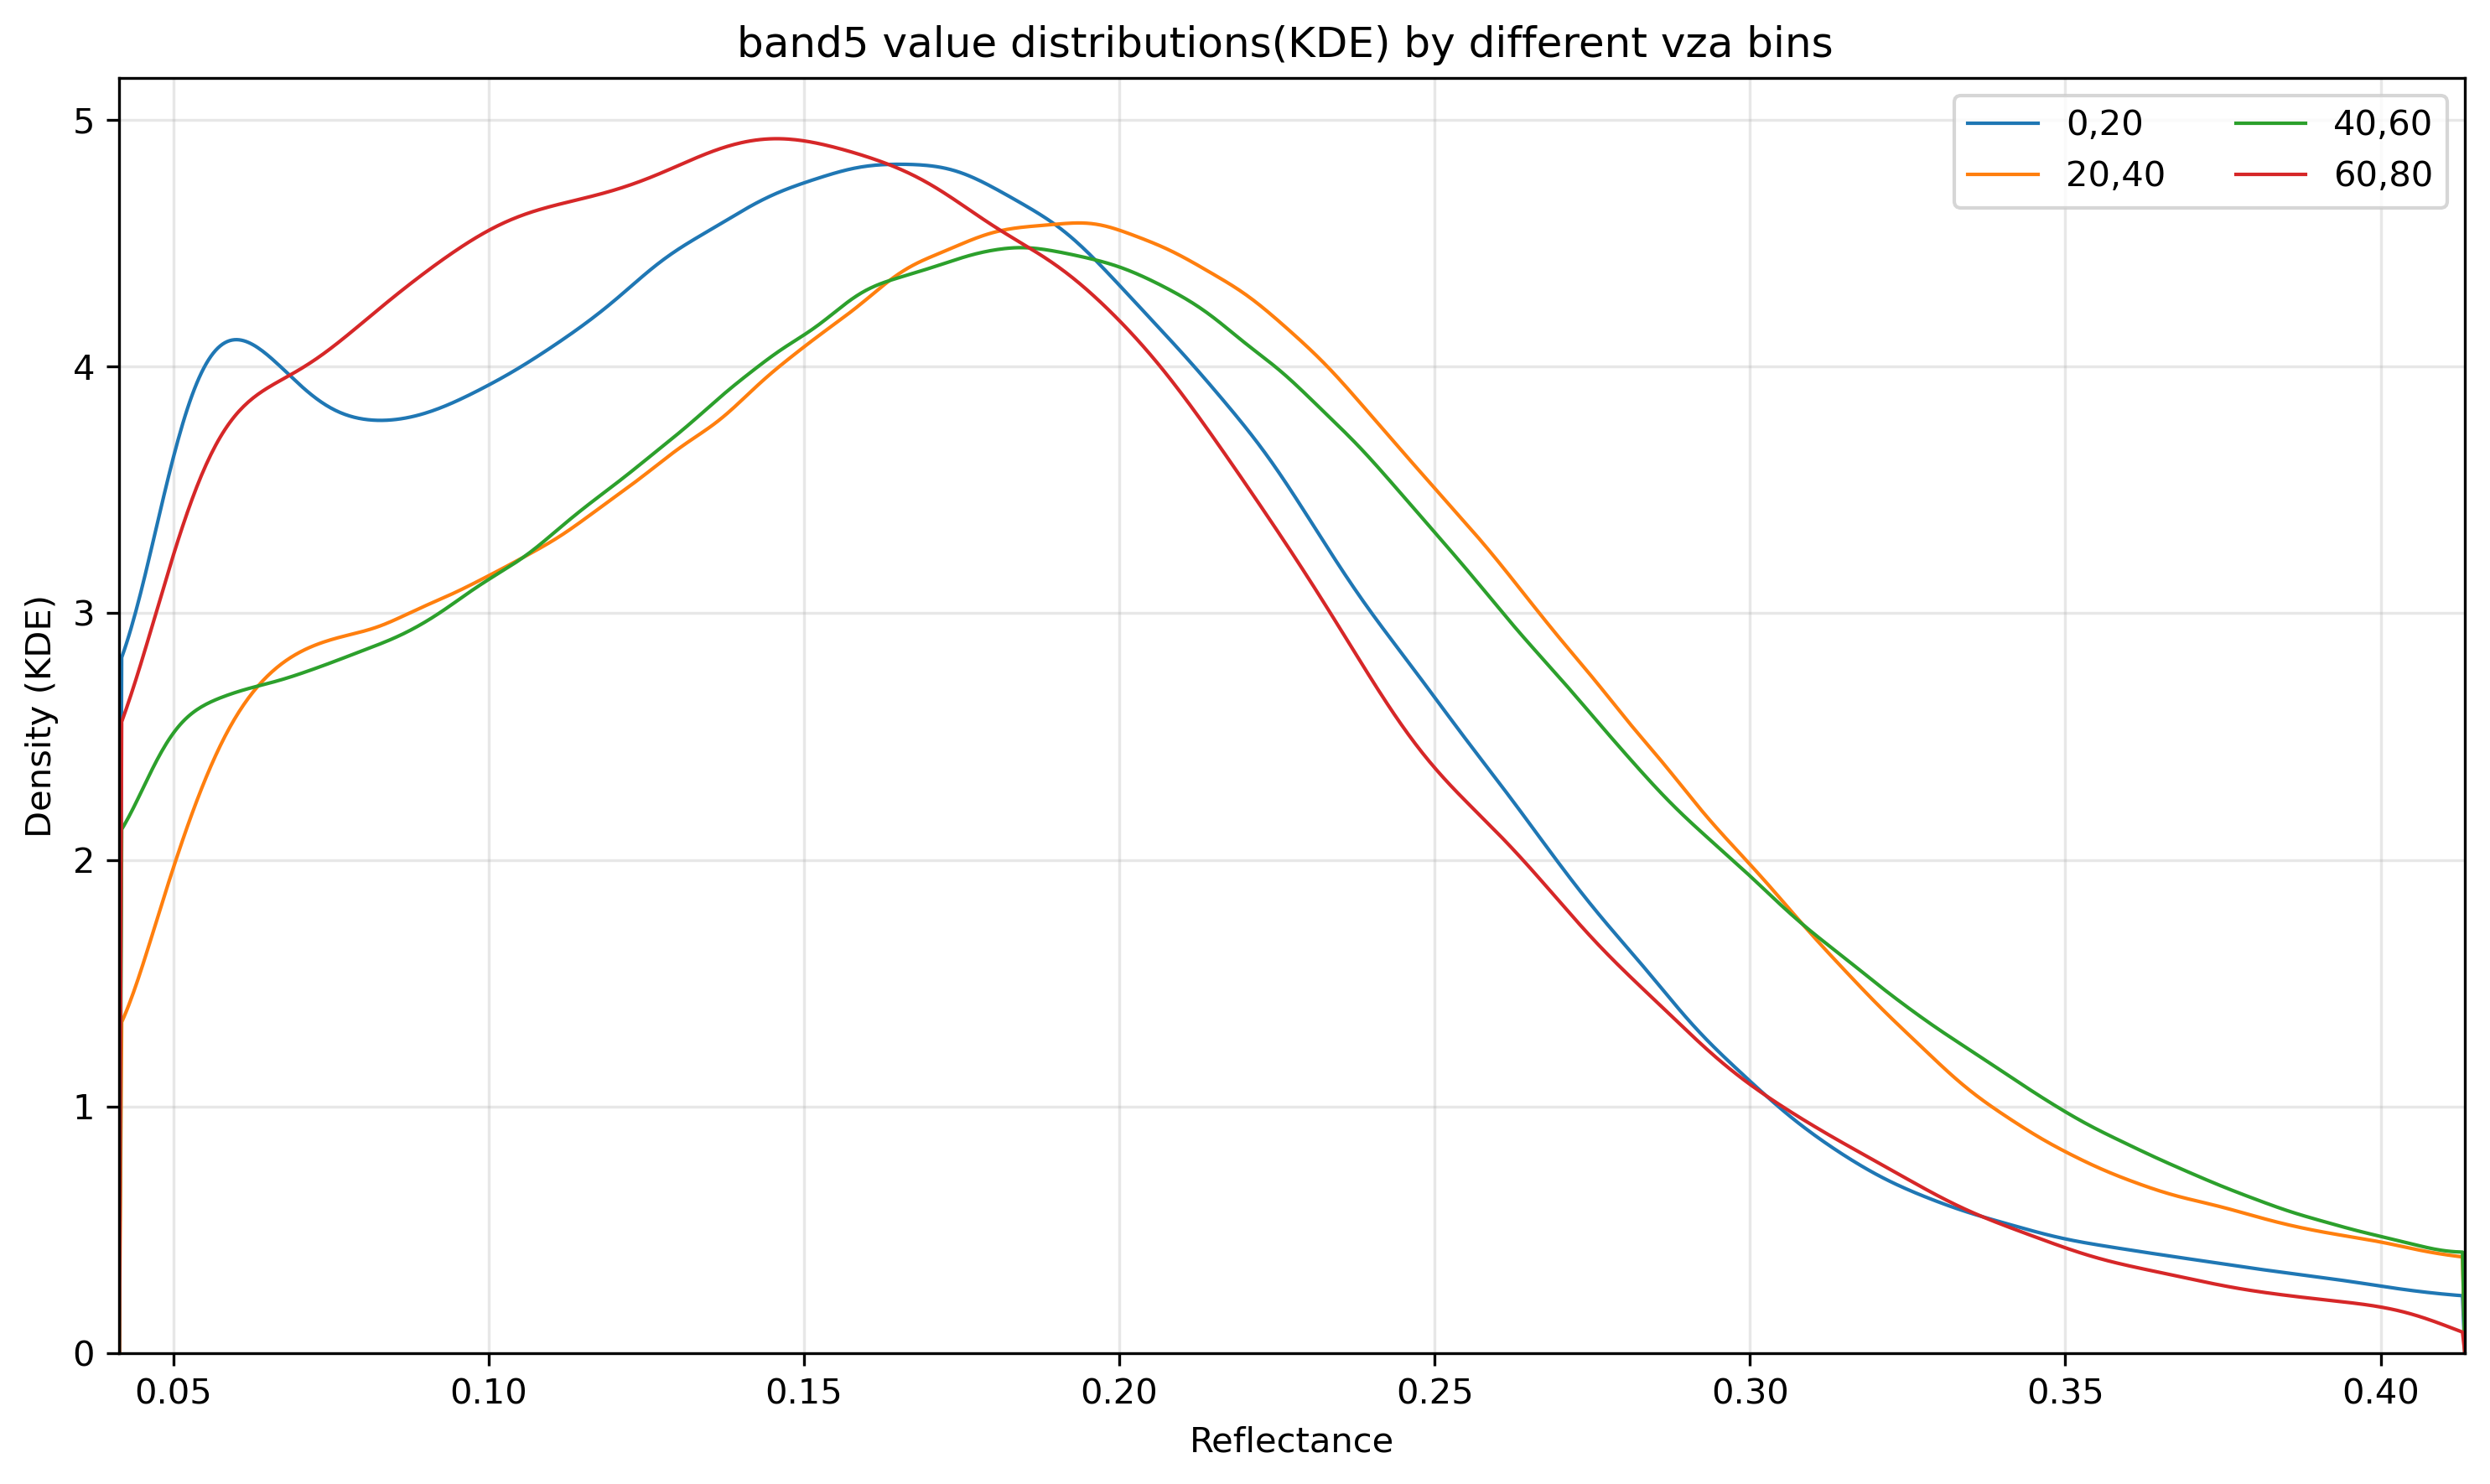

In [12]:

dataframe_d = pl.read_parquet("/run/media/mak/Heim/2024/20240826_week8/metashape/20241029_products_uav_data/output/extract/polygon_df/plot_18.parquet")
dataframe_d = dataframe_d.drop_nans()


# Convert sun elevation to zenith angle
dataframe_d = dataframe_d.with_columns((90 - pl.col("sunelev")).alias("sza"))

# Calculate relative azimuth angle constrained to [0,180]
dataframe_d = dataframe_d.with_columns(
    (((pl.col("saa") - pl.col("vaa") + 180) % 360) - 180).alias("RAA")
)

for band in [f"band{i}" for i in range(5,6)]:
    angle_kde_plot(dataframe_d, band=band, bins=vza_bins, points=1000, linewidth=1, colors=None, dpi=300, xlim=None, angle='vza')





0.04144645109772682 0.4133579134941101


/tmp/ipykernel_4720/1111078562.py:140: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_k.show()


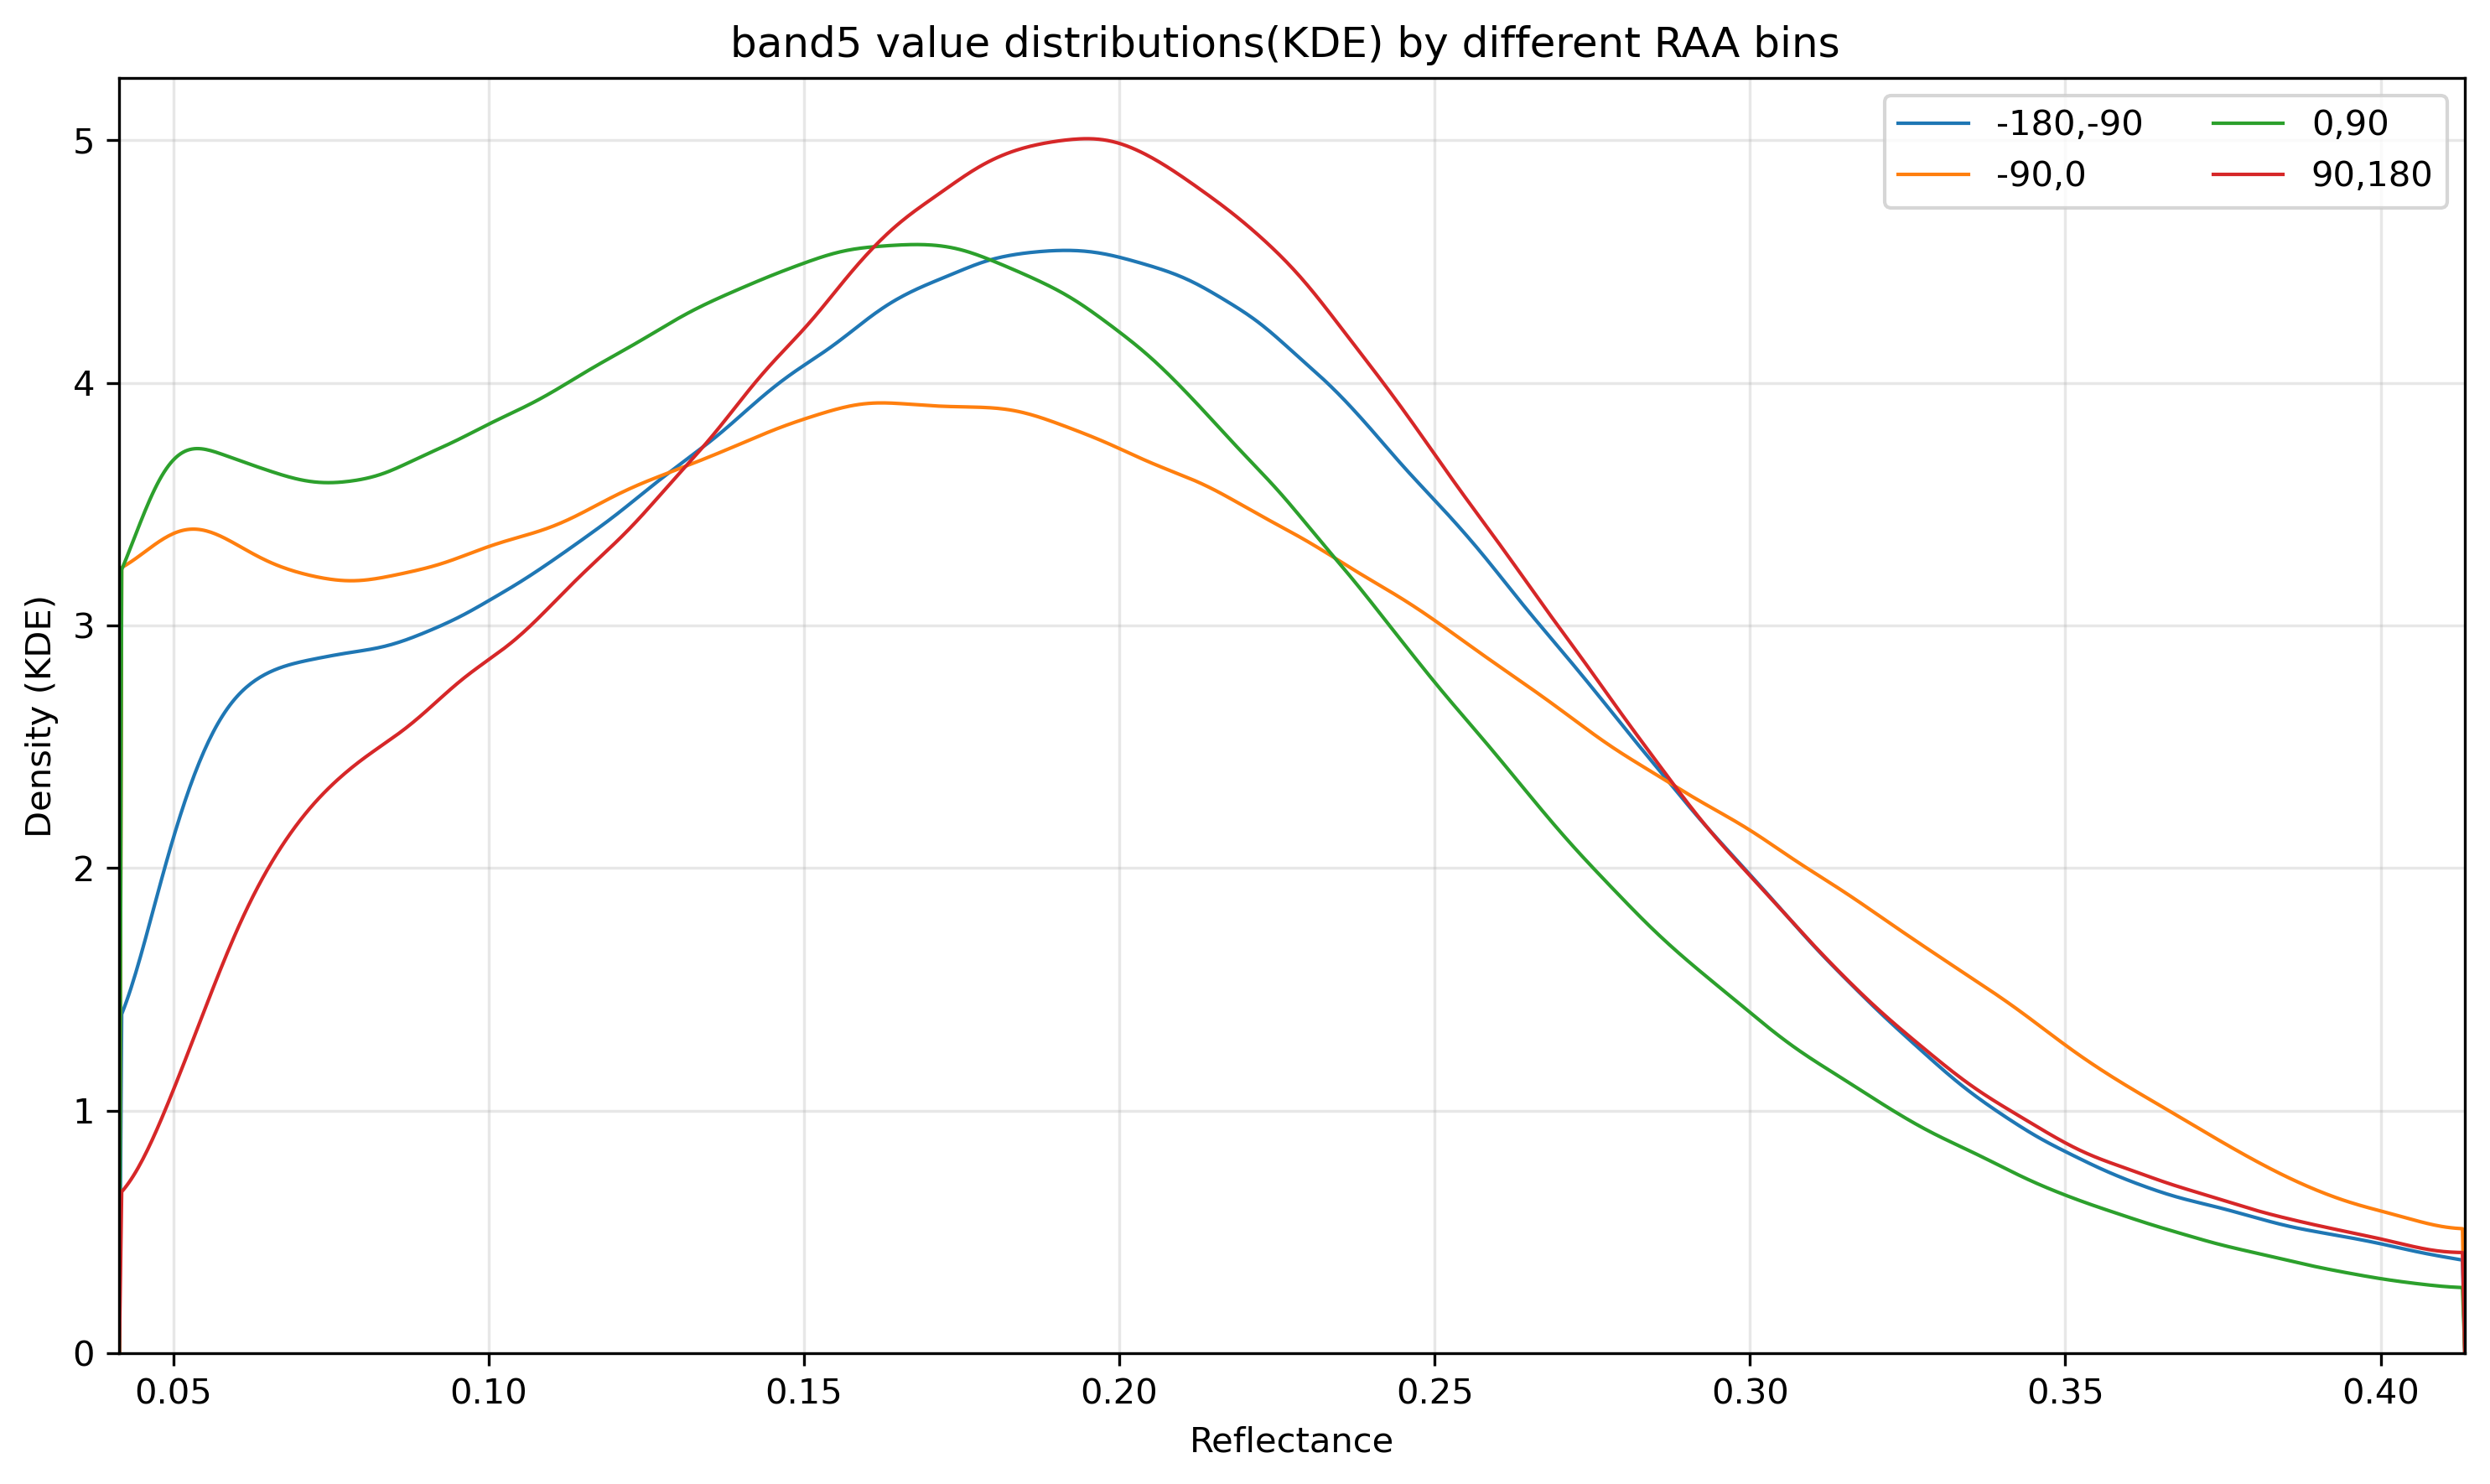

In [13]:
for band in [f"band{i}" for i in range(5,6)]:
    angle_kde_plot(dataframe_d, band=band, bins=vaa_bins, points=1000, linewidth=1, colors=None, dpi=300, xlim=None, angle='RAA')

In [14]:
def assign_bin(v):
    for lo, hi in vaa_bins:
        if lo <= v < hi:
            return f"{lo}-{hi}"   # hashable
    return None

dataframe_d = dataframe_d.with_columns(
    pl.col("RAA").map_elements(assign_bin, return_dtype=pl.Utf8).alias("raa_bin")
).drop_nulls("raa_bin")


def assign_bin(v):
    for lo, hi in vza_bins:
        if lo <= v < hi:
            return f"{lo}-{hi}"
    return None

dataframe_d = dataframe_d.with_columns(
    pl.col("vza").map_elements(assign_bin, return_dtype=pl.Utf8).alias("vza_bin")
).drop_nulls("vza_bin")






In [15]:
ANOVA_optimized(dataframe=dataframe_d, band_col="band5", col = "raa_bin")


group1,group2,mean group 2 - group1,CI+-,p_text,-log10_p,cohens_d,reject,F_global,degrees of freedom,eta_sq
str,str,f64,f64,str,f64,f64,bool,f64,f64,f64
"""0-90""","""90-180""",0.027574,0.000648,"""p < 0.0001""",323.306,0.316,true,52218.150643,2.0370e-7,0.011
"""-180--90""","""0-90""",-0.020945,0.000567,"""p < 0.0001""",323.306,0.234,true,52218.150643,2.0370e-7,0.011
"""0-90""","""-90-0""",0.020689,0.000745,"""p < 0.0001""",323.306,0.221,true,52218.150643,2.0370e-7,0.011
"""-180--90""","""90-180""",0.006629,0.000536,"""p < 0.0001""",323.306,0.075,true,52218.150643,2.0370e-7,0.011
"""-90-0""","""90-180""",0.006885,0.000722,"""p < 0.0001""",323.306,0.075,true,52218.150643,2.0370e-7,0.011
"""-180--90""","""-90-0""",-0.000256,0.00065,"""6.751e-02""",1.171,0.003,false,52218.150643,2.0370e-7,0.011


In [16]:
ANOVA_optimized(dataframe=dataframe_d, band_col="band5", col = "vza_bin")


group1,group2,mean group 2 - group1,CI+-,p_text,-log10_p,cohens_d,reject,F_global,degrees of freedom,eta_sq
str,str,f64,f64,str,f64,f64,bool,f64,f64,f64
"""60-80""","""20-40""",0.031336,0.002201,"""p < 0.0001""",323.306,0.349,true,31380.420897,2.0370e-7,0.006
"""40-60""","""60-80""",-0.030666,0.002201,"""p < 0.0001""",323.306,0.333,true,31380.420897,2.0370e-7,0.006
"""0-20""","""20-40""",0.026224,0.000836,"""p < 0.0001""",323.306,0.294,true,31380.420897,2.0370e-7,0.006
"""40-60""","""0-20""",-0.025553,0.000837,"""p < 0.0001""",323.306,0.28,true,31380.420897,2.0370e-7,0.006
"""0-20""","""60-80""",-0.005112,0.002314,"""p < 0.0001""",323.306,0.061,true,31380.420897,2.0370e-7,0.006
"""40-60""","""20-40""",0.00067,0.000433,"""p < 0.0001""",323.306,0.007,true,31380.420897,2.0370e-7,0.006


# OLS

In [27]:
import polars as pl, statsmodels.formula.api as smf
from scipy import stats

common = set(dataframe.columns) & set(dataframe_d.columns)  # align schemas
df = pl.concat([
    dataframe.select(common).with_columns(pl.lit("healthy").alias("status")),
    dataframe_d.select(common).with_columns(pl.lit("diseased").alias("status"))
])
df = df.with_columns([pl.col("status").cast(pl.Categorical),
                      pl.col("vza_bin").cast(pl.Categorical),
                      pl.col("raa_bin").cast(pl.Categorical)])
n = min(500_000, df.height)  # cap size to keep fit tractable
df = df.sample(n, with_replacement=False, shuffle=True)
d = df.to_pandas()

m0 = smf.ols("band5 ~ C(status) + C(vza_bin) + C(raa_bin)", data=d).fit()
m1 = smf.ols("band5 ~ C(status)*C(vza_bin)*C(raa_bin)", data=d).fit()      # add all interactions
lrt = 2*(m1.llf - m0.llf); df_diff = int(m1.df_model - m0.df_model)
p = stats.chi2.sf(lrt, df_diff)
print({"LRT": lrt, "df": df_diff, "p": p, "ΔAIC": m0.aic - m1.aic, "ΔBIC": m0.bic - m1.bic})



{'LRT': np.float64(17027.285480504856), 'df': 21, 'p': np.float64(0.0), 'ΔAIC': np.float64(16985.285480504856), 'ΔBIC': np.float64(16751.71584957943)}


Using the same observations for both models, adding view-geometry interactions improved fit dramatically (χ²(21) = 17027, p < 1e−16), with ΔAIC = 16985 and ΔBIC = 16752 favoring the interaction model. This confirms that differences in reflectance between healthy and diseased plants depend on VZA and relative azimuth.

In [35]:
import pandas as pd, statsmodels.formula.api as smf
from scipy.stats import chi2
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

# --- OLS on identical rows ---
nd = d.query("vza < 20").copy()
m_nadir = smf.ols("band5 ~ C(status)", data=nd).fit()
m_main  = smf.ols("band5 ~ C(status) + C(vza_bin) + C(raa_bin)", data=d).fit()
m1      = smf.ols("band5 ~ C(status)*C(vza_bin)*C(raa_bin)", data=d).fit()

def cmp(a,b):
    LRT = 2*(b.llf - a.llf); df = int(b.df_model - a.df_model); p = chi2.sf(LRT, df)
    return {"LRT": LRT, "df": df, "p": p, "ΔAIC": a.aic - b.aic, "ΔBIC": a.bic - b.bic}

res = {
  "nadir→main": cmp(m_nadir, m_main),
  "main→full":  cmp(m_main, m1),
  "nadir→full": cmp(m_nadir, m1)
}

# --- AUROC: nadir subset vs geometry-aware full ---
nd = d.query("vza < 20")
au_nadir = cross_val_score(LogisticRegression(max_iter=2000), nd[["band5"]],
                           (nd["status"]=="diseased").astype(int), cv=5, scoring="roc_auc").mean()


X_geo = pd.get_dummies(d[["band5","vza_bin","raa_bin"]], drop_first=True)
au_geo = cross_val_score(LogisticRegression(max_iter=2000), X_geo,
                         (d["status"]=="diseased").astype(int), cv=5, scoring="roc_auc").mean()

print({"LRT": res, "AUROC_nadir": au_nadir, "AUROC_angle": au_geo, "ΔAUROC": au_geo-au_nadir})


{'LRT': {'nadir→main': {'LRT': np.float64(827123.4549327899), 'df': 6, 'p': np.float64(0.0), 'ΔAIC': np.float64(827111.4549327899), 'ΔBIC': np.float64(827039.6453524933)}, 'main→full': {'LRT': np.float64(17027.285480504856), 'df': 21, 'p': np.float64(0.0), 'ΔAIC': np.float64(16985.285480504856), 'ΔBIC': np.float64(16751.71584957943)}, 'nadir→full': {'LRT': np.float64(844150.7404132948), 'df': 27, 'p': np.float64(0.0), 'ΔAIC': np.float64(844096.7404132948), 'ΔBIC': np.float64(843791.3612020727)}}, 'AUROC_nadir': np.float64(0.8146670992266658), 'AUROC_angle': np.float64(0.8812901733783913), 'ΔAUROC': np.float64(0.06662307415172553)}


In [37]:

import patsy

y = (d["status"].astype(str).str.lower()=="diseased").astype(int)

# main effects
X_main = patsy.dmatrix("band5 + C(vza_bin) + C(raa_bin)", d, return_type='dataframe')
au_main = cross_val_score(LogisticRegression(max_iter=2000), X_main, y, cv=5, scoring="roc_auc").mean()

# full interactions
X_full = patsy.dmatrix("band5 * C(vza_bin) * C(raa_bin)" , d, return_type='dataframe')
au_full = cross_val_score(LogisticRegression(max_iter=2000), X_full, y, cv=5, scoring="roc_auc").mean()

# nadir baseline on vza<20°
nd = d.query("vza < 20")
au_nadir = cross_val_score(LogisticRegression(max_iter=2000), nd[["band5"]],
                           (nd["status"].str.lower()=="diseased").astype(int),
                           cv=5, scoring="roc_auc").mean()

print({"AUROC_nadir": au_nadir, "AUROC_main": au_main, "AUROC_full": au_full,
       "Δ_main−nadir": au_main - au_nadir, "Δ_full−main": au_full - au_main})

{'AUROC_nadir': np.float64(0.8146670992266658), 'AUROC_main': np.float64(0.881309121452628), 'AUROC_full': np.float64(0.8984158527059772), 'Δ_main−nadir': np.float64(0.06664202222596216), 'Δ_full−main': np.float64(0.017106731253349272)}


In [28]:
import numpy as np, pandas as pd

def cohen_d(sub):                              # pooled-SD d (diseased - healthy)
    g = sub.groupby("status")["band5"].agg(["mean","std","count"])
    m1,m0 = g.loc["diseased","mean"], g.loc["healthy","mean"]
    s1,s0 = g.loc["diseased","std"],  g.loc["healthy","std"]
    n1,n0 = g.loc["diseased","count"],g.loc["healthy","count"]
    sp = np.sqrt(((n1-1)*s1**2 + (n0-1)*s0**2) / (n1+n0-2))
    return (m1 - m0)/sp

baseline = cohen_d(d.query("vza < 20"))        # nadir-ish baseline
perbin = d.groupby(["vza_bin","raa_bin"]).apply(cohen_d).rename("d")
top = perbin.reindex(perbin.abs().sort_values(ascending=False).index)[:5]
print({"Cohen_d_nadir": baseline, "top_bins_by_|d|": top.to_dict()})


{'Cohen_d_nadir': np.float64(-1.479148665513763), 'top_bins_by_|d|': {('20-40', '-90-0'): -2.7189590024190373, ('20-40', '0-90'): -2.4143112834084075, ('40-60', '0-90'): -2.229425084491822, ('60-80', '0-90'): -2.189793075809151, ('0-20', '90-180'): -2.0213925321074613}}


/tmp/ipykernel_4720/2592166036.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = sub.groupby("status")["band5"].agg(["mean","std","count"])
/tmp/ipykernel_4720/2592166036.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  perbin = d.groupby(["vza_bin","raa_bin"]).apply(cohen_d).rename("d")
/tmp/ipykernel_4720/2592166036.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = sub.groupby("status")["band5"].agg(["m

In [26]:
from statsmodels.stats.anova import anova_lm
tab = anova_lm(m1, typ=3)                      # includes sum_sq per term

def eta2p(term):
    if term not in tab.index: return np.nan
    ss = tab.loc[term,"sum_sq"]; return ss/(ss + tab.loc["Residual","sum_sq"])

terms = ["C(status):C(vza_bin)", "C(status):C(raa_bin)", "C(status):C(vza_bin):C(raa_bin)"]
print({t: eta2p(t) for t in terms})


/home/mak/miniforge3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 9, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/home/mak/miniforge3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 9, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/home/mak/miniforge3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 9, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/home/mak/miniforge3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 81, but rank is 5
  warnings.warn('covariance of cons

{'C(status):C(vza_bin)': np.float64(0.0001971001844202378), 'C(status):C(raa_bin)': np.float64(0.00023070304856593555), 'C(status):C(vza_bin):C(raa_bin)': np.float64(0.0017779364541603236)}


/home/mak/miniforge3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 729, but rank is 5
  warnings.warn('covariance of constraints does not have full '


In [24]:
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

y  = (d["status"]=="diseased").astype(int)
X0 = d[["band5"]]  # nadir proxy
X1 = pd.get_dummies(d[["band5","vza_bin","raa_bin"]], drop_first=True)

clf = LogisticRegression(max_iter=2000)
au0 = cross_val_score(clf, X0, y, cv=5, scoring="roc_auc").mean()
au1 = cross_val_score(clf, X1, y, cv=5, scoring="roc_auc").mean()
print({"AUROC_nadir": au0, "AUROC_angle": au1, "ΔAUROC": au1-au0})


{'AUROC_nadir': np.float64(0.8258658763799872), 'AUROC_angle': np.float64(0.882169452405488), 'ΔAUROC': np.float64(0.056303576025500846)}


In [22]:
m1.pvalues.filter(like="C(status)[T.diseased]:C(vza_bin)")

C(status)[T.diseased]:C(vza_bin)[T.diseased]                           0.337269
C(status)[T.diseased]:C(vza_bin)[T.60-80]                              0.129542
C(status)[T.diseased]:C(vza_bin)[T.20-40]                              0.132199
C(status)[T.diseased]:C(vza_bin)[T.40-60]                              0.232517
C(status)[T.diseased]:C(vza_bin)[T.0-20]                               0.120524
                                                                         ...   
C(status)[T.diseased]:C(vza_bin)[T.0-20]:C(raa_bin)[T.-180--90]        0.036572
C(status)[T.diseased]:C(vza_bin)[T.90-180]:C(raa_bin)[T.-180--90]           NaN
C(status)[T.diseased]:C(vza_bin)[T.0-90]:C(raa_bin)[T.-180--90]             NaN
C(status)[T.diseased]:C(vza_bin)[T.-90-0]:C(raa_bin)[T.-180--90]            NaN
C(status)[T.diseased]:C(vza_bin)[T.-180--90]:C(raa_bin)[T.-180--90]         NaN
Length: 90, dtype: float64

Relative to a nadir-proxy subset, incorporating view geometry increased AUROC from 0.826 to 0.882 (Δ=0.056). Cohen’s d for diseased vs healthy reflectance strengthened from 1.47 at nadir to 2.21–2.75 in several bins centered at VZA 20–40° along the principal plane. A nested model comparison on the full dataset confirmed significant status×angle interactions, indicating multi-angular observations explain class differences more effectively than nadir-only.

In [18]:
import polars as pl
import numpy as np
from scipy.stats import ttest_ind, spearmanr
from scipy.stats import t as t_dist
import matplotlib.pyplot as plt

def calculate_geometry(dataframe):
    """
    Calculate angular geometry parameters from solar/viewing angles.

    Parameters:
        dataframe: Polars DataFrame with sunelev, saa, vaa columns

    Returns:
        Polars DataFrame with added phase angle and RAA columns
    """
    rad = np.pi / 180  # Conversion factor from degrees to radians

    return (
        dataframe.lazy()
        # Convert sun elevation to zenith angle
        .with_columns((90 - pl.col("sunelev")).alias("sza"))
        # Calculate relative azimuth angle constrained to [0,180]
        .with_columns(
            pl.min_horizontal(
                (pl.col("saa") - pl.col("vaa")).abs(),
                360 - (pl.col("saa") - pl.col("vaa")).abs(),
            ).alias("RAA")
        )
        # Calculate phase angle (degrees) using the law of cosines for spherical triangles
        .with_columns(
            (
                (
                    (pl.col("sza") * rad).cos() * (pl.col("vza") * rad).cos() +
                    (pl.col("sza") * rad).sin() * (pl.col("vza") * rad).sin() *
                    (pl.col("RAA") * rad).cos()
                )
                .clip(-1.0, 1.0)  # Prevent numerical errors in arccos
                .arccos() / rad
            ).alias("phase")
        )
        .collect(streaming=True)
    )

def calculate_hot_spot_index(df, g0=5, ref_range=(20, 30), band="band5", raa_max=10):
    """
    Calculate the Hot Spot Index (HSI) and related statistics.

    Parameters:
        df: Polars DataFrame with phase, RAA, and band columns
        g0: Maximum phase angle for hot spot region (degrees)
        ref_range: Tuple with min and max phase angles for reference region (degrees)
        band: Column name for the spectral band to analyze
        raa_max: Maximum relative azimuth angle to include (backscatter plane)

    Returns:
        Dict with HSI metrics and statistical test results
    """
    # Filter to just backscatter plane (low RAA)
    backscatter_df = df.filter(pl.col("RAA") <= raa_max)

    # Extract hot spot region (phase <= g0)
    hotspot_samples = backscatter_df.filter(pl.col("phase") <= g0)[band].to_numpy()

    # Extract reference region (ref_range[0] <= phase <= ref_range[1])
    ref_min, ref_max = ref_range
    reference_samples = backscatter_df.filter(
        (pl.col("phase") >= ref_min) &
        (pl.col("phase") <= ref_max)
    )[band].to_numpy()

    # Calculate Hot Spot Index (difference between means)
    hsi_value = float(hotspot_samples.mean() - reference_samples.mean())

    # Welch's t-test (unequal variances)
    t_statistic, p_value = ttest_ind(hotspot_samples, reference_samples, equal_var=False)

    # Calculate additional statistics for the HSI
    stats = calculate_effect_size(hotspot_samples, reference_samples)

    # Spearman correlation for forward scattering trend (phase <= 30°)
    forward_df = backscatter_df.filter(pl.col("phase") <= 30)
    rho, p_rho = spearmanr(forward_df["phase"].to_numpy(), forward_df[band].to_numpy())

    # Compile results
    results = {
        "HSI": hsi_value,
        "Welch_t": float(t_statistic),
        "p_value": float(p_value),
        "Spearman_rho": float(rho),
        "p_rho": float(p_rho),
        "n_hotspot": len(hotspot_samples),
        "n_reference": len(reference_samples),
        "CI95": stats["CI95"],
        "cohens_d": stats["cohens_d"],
        "rel_change": stats["rel_change"]
    }

    return results

def calculate_effect_size(a, b):
    """
    Calculate effect sizes and confidence intervals for the difference between means.

    Parameters:
        a: NumPy array with hot spot samples
        b: NumPy array with reference samples

    Returns:
        Dict with confidence intervals and effect sizes
    """
    # Calculate means and standard deviations
    m1, m2 = a.mean(), b.mean()
    s1, s2 = a.std(ddof=1), b.std(ddof=1)
    n1, n2 = len(a), len(b)

    # Mean difference
    delta = m1 - m2

    # Standard error (Welch's t-test)
    se = np.sqrt(s1*s1/n1 + s2*s2/n2)

    # Degrees of freedom (Welch-Satterthwaite equation)
    df = (s1*s1/n1 + s2*s2/n2)**2 / ((s1*s1/n1)**2/(n1-1) + (s2*s2/n2)**2/(n2-1))

    # Critical t-value for 95% confidence interval
    crit = t_dist.ppf(0.975, df)

    # 95% confidence interval
    ci = (delta - crit*se, delta + crit*se)

    # Pooled standard deviation for Cohen's d
    sp = np.sqrt(((n1-1)*s1*s1 + (n2-1)*s2*s2) / (n1+n2-2))

    # Cohen's d effect size
    d = delta / sp

    # Relative change
    rel = delta / m2

    return {
        "CI95": (float(ci[0]), float(ci[1])),
        "cohens_d": float(d),
        "rel_change": float(rel)
    }

def print_hsi_results(results):
    """
    Print formatted results of the HSI analysis.
    """
    print("\n" + "="*60)
    print("HOT SPOT INDEX (HSI) ANALYSIS RESULTS")
    print("="*60)

    # Main HSI metrics
    print("\nHOT SPOT INDEX METRICS:")
    print(f"HSI Value:                  {results['HSI']:.4f}")
    print(f"95% Confidence Interval:    ({results['CI95'][0]:.4f}, {results['CI95'][1]:.4f})")
    print(f"Relative Change:            {results['rel_change']:.2%}")

    # Effect size
    print("\nEFFECT SIZE:")
    print(f"Cohen's d:                  {results['cohens_d']:.4f}")

    # Statistical tests
    print("\nSTATISTICAL TESTS:")
    print(f"Welch's t-statistic:        {results['Welch_t']:.4f}")
    print(f"p-value (t-test):           {results['p_value']:.6f} " +
          ("(significant)" if results['p_value'] < 0.05 else "(not significant)"))
    print(f"Spearman's rho:             {results['Spearman_rho']:.4f}")
    print(f"p-value (Spearman):         {results['p_rho']:.6f} " +
          ("(significant)" if results['p_rho'] < 0.05 else "(not significant)"))

    # Sample sizes
    print("\nSAMPLE SIZES:")
    print(f"Hot spot samples (g ≤ 5°):  {results['n_hotspot']}")
    print(f"Reference samples (20-30°): {results['n_reference']}")
    print("="*60 + "\n")

def plot_hsi_results(df, results, g0=5, ref_range=(20, 30), band="band5", raa_max=10):
    """
    Create a visualization of the HSI analysis.
    """
    backscatter_df = df.filter(pl.col("RAA") <= raa_max)

    # Convert to pandas for easier plotting
    pdf = backscatter_df.to_pandas()

    plt.figure(figsize=(12, 6))

    # Scatter plot
    plt.scatter(pdf["phase"], pdf[band], alpha=0.3, color="gray", label="All measurements")

    # Highlight hot spot and reference regions
    hotspot = pdf[pdf["phase"] <= g0]
    reference = pdf[(pdf["phase"] >= ref_range[0]) & (pdf["phase"] <= ref_range[1])]

    plt.scatter(hotspot["phase"], hotspot[band], color="red", label=f"Hot spot (≤ {g0}°)")
    plt.scatter(reference["phase"], reference[band], color="blue", label=f"Reference ({ref_range[0]}-{ref_range[1]}°)")

    # Add mean lines
    plt.axhline(y=hotspot[band].mean(), color="red", linestyle="--", alpha=0.7)
    plt.axhline(y=reference[band].mean(), color="blue", linestyle="--", alpha=0.7)

    # Annotate HSI
    plt.annotate(f"HSI = {results['HSI']:.4f}",
                xy=(0.7, 0.9),
                xycoords='axes fraction',
                bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="orange", alpha=0.8))

    plt.xlabel("Phase angle (degrees)")
    plt.ylabel(f"Reflectance ({band})")
    plt.title("Hot Spot Index Analysis")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    return plt

# Calculate geometry parameters
df = calculate_geometry(dataframe.drop_nans())

# Define HSI parameters
g0 = 10
ref_range = (10, 25)
band = "band5"
raa_max = 10

# Calculate HSI and related statistics
results = calculate_hot_spot_index(df, g0, ref_range, band, raa_max)

# Print formatted results
print_hsi_results(results)






HOT SPOT INDEX (HSI) ANALYSIS RESULTS

HOT SPOT INDEX METRICS:
HSI Value:                  -0.0020
95% Confidence Interval:    (-0.0055, 0.0014)
Relative Change:            -0.57%

EFFECT SIZE:
Cohen's d:                  -0.0145

STATISTICAL TESTS:
Welch's t-statistic:        -1.1482
p-value (t-test):           0.250936 (not significant)
Spearman's rho:             -0.0146
p-value (Spearman):         0.000000 (significant)

SAMPLE SIZES:
Hot spot samples (g ≤ 5°):  162050
Reference samples (20-30°): 4260



/tmp/ipykernel_44825/2060635456.py:43: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)
